In [1]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import movie_recommender.data as movie_data

importlib.reload(movie_data)

build_movie_report = movie_data.build_movie_report
build_catalog_eda_frames = movie_data.build_catalog_eda_frames
build_user_eda_frames = movie_data.build_user_eda_frames
build_user_report = movie_data.build_user_report
prepare_movielens_frames = movie_data.prepare_movielens_frames
search_movies = movie_data.search_movies

DATA_DIR = Path("../movies-database")

movies        = pd.read_csv(DATA_DIR / "movies.csv")
ratings       = pd.read_csv(DATA_DIR / "ratings.csv")
tags          = pd.read_csv(DATA_DIR / "tags.csv")
links         = pd.read_csv(DATA_DIR / "links.csv")
genome_scores = pd.read_csv(DATA_DIR / "genome-scores.csv")
genome_tags   = pd.read_csv(DATA_DIR / "genome-tags.csv")

print("movies:       ", movies.shape)
print("ratings:      ", ratings.shape)
print("tags:         ", tags.shape)
print("links:        ", links.shape)
print("genome_scores:", genome_scores.shape)
print("genome_tags:  ", genome_tags.shape)

movies:        (62423, 3)
ratings:       (25000095, 4)
tags:          (1093360, 4)
links:         (62423, 3)
genome_scores: (15584448, 3)
genome_tags:   (1128, 2)


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Training spine  (25 M rows, stays lean)
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# Only merge the lightweight metadata you actually need per-rating.
# Keep genome completely out of this frame.
train = (
    ratings[["userId", "movieId", "rating", "timestamp"]]
    .merge(movies[["movieId", "genres"]], on="movieId", how="left")
)

# User-mean-centered rating — critical for many CF models (SVD, ALS, NCF).
user_mean = train.groupby("userId")["rating"].transform("mean")
train["rating_norm"] = (train["rating"] - user_mean).astype("float32")

# Lightweight datetime features for temporal models.
train["year_rated"]  = pd.to_datetime(train["timestamp"], unit="s").dt.year
train["month_rated"] = pd.to_datetime(train["timestamp"], unit="s").dt.month

print(train.shape)          # (25_000_095, 7)  — fine
print(train.dtypes)

(25000095, 8)
userId           int64
movieId          int64
rating         float64
timestamp        int64
genres          object
rating_norm    float32
year_rated       int32
month_rated      int32
dtype: object


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Genre one-hot  (62 K × 19 cols)
# ─────────────────────────────────────────────────────────────────────────────
genre_dummies = (
    movies.set_index("movieId")["genres"]
    .str.get_dummies("|")
    .drop(columns=["(no genres listed)"], errors="ignore")
    .add_prefix("genre_")
    .astype("int8")           # saves memory vs int64
)
print(genre_dummies.shape)  # (62_423, 19)

(62423, 19)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Genome: pivot to WIDE once (13 816 × 1 128 ≈ 120 MB in float32)
#           Store as a separate lookup — never join to ratings.
# ─────────────────────────────────────────────────────────────────────────────
tag_id_to_name = genome_tags.set_index("tagId")["tag"]

genome_wide = (
    genome_scores
    .pivot(index="movieId", columns="tagId", values="relevance")
    .astype("float32")
)
genome_wide.columns = [tag_id_to_name.get(t, str(t)) for t in genome_wide.columns]

print(genome_wide.shape)    # (13_816, 1_128)

(13816, 1128)


## Train / Test Split
**Temporal split** is mandatory for recommenders — random split leaks future ratings into training.
Strategy: globally sort by timestamp, hold out the last 20 % as test.
All three models (SVD, MF, NCF) share the same split so results are comparable.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Temporal split — 80 % train / 20 % test (by timestamp, NOT random)
# ─────────────────────────────────────────────────────────────────────────────
cutoff_ts = train["timestamp"].quantile(0.80)

df_train = train[train["timestamp"] <= cutoff_ts].copy()
df_test  = train[train["timestamp"] >  cutoff_ts].copy()

# Drop cold-start rows from test: users/movies never seen during training.
# Baseline models can't predict for unseen IDs — handle cold-start separately later.
known_users  = set(df_train["userId"])
known_movies = set(df_train["movieId"])
df_test = df_test[
    df_test["userId"].isin(known_users) &
    df_test["movieId"].isin(known_movies)
].copy()

print(f"Train : {len(df_train):>10,}  rows  ({len(df_train)/len(train):.1%})")
print(f"Test  : {len(df_test):>10,}  rows  ({len(df_test)/len(train):.1%})")
print(f"Dropped from test (cold-start): {len(train[train['timestamp'] > cutoff_ts]) - len(df_test):,}")


Train : 20,000,076  rows  (80.0%)
Test  :    610,664  rows  (2.4%)
Dropped from test (cold-start): 4,389,355


## Feature Engineering — Genre Side Features

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Attach genre one-hots to train / test splits
# genre_dummies is indexed by movieId (from cell above), so a simple join works.
# ─────────────────────────────────────────────────────────────────────────────
GENRE_COLS = genre_dummies.columns.tolist()   # e.g. ['genre_Action', ...]
N_GENRES   = len(GENRE_COLS)

df_train = df_train.join(genre_dummies, on="movieId")
df_test  = df_test.join(genre_dummies,  on="movieId")

# Fill any movie that has no genre listing with zeros
df_train[GENRE_COLS] = df_train[GENRE_COLS].fillna(0).astype("float32")
df_test[GENRE_COLS]  = df_test[GENRE_COLS].fillna(0).astype("float32")

print(f"Genre columns added: {N_GENRES}")
print(df_train[GENRE_COLS].head(3))

Genre columns added: 19
   genre_Action  genre_Adventure  genre_Animation  genre_Children  \
0           0.0              0.0              0.0             0.0   
1           0.0              0.0              0.0             0.0   
2           0.0              0.0              0.0             0.0   

   genre_Comedy  genre_Crime  genre_Documentary  genre_Drama  genre_Fantasy  \
0           1.0          1.0                0.0          1.0            0.0   
1           0.0          0.0                0.0          1.0            0.0   
2           0.0          0.0                0.0          1.0            0.0   

   genre_Film-Noir  genre_Horror  genre_IMAX  genre_Musical  genre_Mystery  \
0              0.0           0.0         0.0            0.0            0.0   
1              0.0           0.0         0.0            0.0            0.0   
2              0.0           0.0         0.0            0.0            0.0   

   genre_Romance  genre_Sci-Fi  genre_Thriller  genre_War  genre_West

## Integer Encoding & Sparse Matrix
Both sparse-matrix methods (SVD, MF) and embedding layers (NCF) require contiguous
0-based integer indices. Build the lookup dicts from the **training set only** so
test never leaks new IDs into the vocabulary.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Integer encoding — fit on training set only
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
from scipy.sparse import csr_matrix

user_ids  = np.sort(df_train["userId"].unique())
movie_ids = np.sort(df_train["movieId"].unique())

user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

N_USERS  = len(user_to_idx)
N_MOVIES = len(movie_to_idx)

for df in [df_train, df_test]:
    df["user_idx"]  = df["userId"].map(user_to_idx).astype("int32")
    df["movie_idx"] = df["movieId"].map(movie_to_idx).astype("int32")

print(f"N_USERS={N_USERS:,}   N_MOVIES={N_MOVIES:,}")

# ─────────────────────────────────────────────────────────────────────────────
# Sparse user-item matrix (for SVD and MF baseline)
# rating_norm is user-mean-centred: 0 = unobserved, near-0 = average preference.
# ─────────────────────────────────────────────────────────────────────────────
R_train = csr_matrix(
    (df_train["rating_norm"].values,
     (df_train["user_idx"].values, df_train["movie_idx"].values)),
    shape=(N_USERS, N_MOVIES),
    dtype="float32",
)

user_mean_map = df_train.groupby("user_idx")["rating"].mean()

print(f"Sparse matrix: {R_train.shape}")
print(f"  nnz        : {R_train.nnz:,}")
print(f"  density    : {R_train.nnz / (N_USERS * N_MOVIES):.4%}")


N_USERS=137,883   N_MOVIES=34,461
Sparse matrix: (137883, 34461)
  nnz        : 20,000,076
  density    : 0.4209%


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Genre-augmented rating matrix — used by SVD and ALS.
# N_GENRES 'pseudo-user' rows are appended so the factorisation must explain
# both user preferences and genre structure simultaneously, giving SVD and ALS
# the same genre signal that genre_proj provides to MF and NCF.
#
# alpha scales genre 0/1 values to match the magnitude of rating_norm (~1.0).
# Treat it like LAM_ALS — tune with a quick sweep over [0.5, 1.0, 2.0].
# ─────────────────────────────────────────────────────────────────────────────
from scipy.sparse import vstack

ALPHA_GENRE = 1.0   # genre signal weight; 0.0 reproduces the ratings-only result

# idx_to_movie and the genre numpy array are also used by the per-user showcase
# — define them here once rather than duplicating in the showcase cell.
idx_to_movie  = {v: k for k, v in movie_to_idx.items()}
all_movie_ids = [idx_to_movie[i] for i in range(N_MOVIES)]
genre_mat     = (genre_dummies
                 .reindex(all_movie_ids)
                 .fillna(0)
                 .values
                 .astype("float32"))          # (N_MOVIES, N_GENRES)

G_pseudo  = csr_matrix((ALPHA_GENRE * genre_mat).T)  # (N_GENRES,  N_MOVIES)
R_aug     = vstack([R_train, G_pseudo], format="csr") # (N_USERS + N_GENRES, N_MOVIES)
N_PSEUDO  = N_GENRES   # number of appended pseudo-user rows

print(f"R_aug : {R_aug.shape}")
print(f"  rating nnz : {R_train.nnz:,}")
print(f"  genre  nnz : {G_pseudo.nnz:,}")
print(f"  total  nnz : {R_aug.nnz:,}")


R_aug : (137902, 34461)
  rating nnz : 20,000,076
  genre  nnz : 64,546
  total  nnz : 20,064,622


## Model 1 — SVD + genre
`scipy.sparse.linalg.svds` decomposes `R_aug` — the rating matrix with genre
pseudo-user rows appended — directly. The resulting `U_aug` is sliced back to
`N_USERS` rows for prediction; the pseudo-user rows act as scaffolding only.
No training loop, no hyperparameters beyond `k` and `ALPHA_GENRE`.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# SVD + genre (via pseudo-user augmentation)
# ─────────────────────────────────────────────────────────────────────────────
from scipy.sparse.linalg import svds

K_SVD = 50  # latent factors; try 20, 50, 100

U_aug, sigma, Vt = svds(R_aug, k=K_SVD)
# svds returns singular values ascending — flip to descending
U_aug, sigma, Vt = U_aug[:, ::-1], sigma[::-1], Vt[::-1, :]

U_svd = U_aug[:N_USERS]   # discard the N_PSEUDO pseudo-user rows

def predict_svd(u_idx, m_idx):
    """Vectorised prediction without materialising the full N x M matrix."""
    return (U_svd[u_idx] * sigma * Vt[:, m_idx].T).sum(axis=1)

preds_norm = predict_svd(df_test["user_idx"].values, df_test["movie_idx"].values)
preds_svd  = np.clip(preds_norm + df_test["user_idx"].map(user_mean_map).values, 0.5, 5.0)

true_ratings = df_test["rating"].values
rmse_svd = np.sqrt(np.mean((preds_svd - true_ratings) ** 2))
mae_svd  = np.mean(np.abs(preds_svd - true_ratings))
print(f"SVD+genre (k={K_SVD}, alpha={ALPHA_GENRE})  RMSE={rmse_svd:.4f}  MAE={mae_svd:.4f}")


SVD+genre (k=50, alpha=1.0)  RMSE=0.9663  MAE=0.7203


## Models 2 & 3 — Matrix Factorisation and Neural CF (PyTorch)
Both architectures are trained sequentially with identical hyperparameters and the same data loaders, so their results are directly comparable.
- **MF (GMF)** — embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
- **NCF** — GMF path *and* an MLP path, fused before the output layer (He et al. 2017).

> **Scale tip:** 25 M rows is large for a CPU training loop. Use `SAMPLE_FRAC=0.10` first
> to verify the pipeline end-to-end, then set it to `1.0` or move to a GPU.

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ── Dataset ───────────────────────────────────────────────────────────────────
class RatingsDataset(Dataset):
    def __init__(self, df, genre_cols):
        self.u = torch.tensor(df["user_idx"].values,  dtype=torch.long)
        self.m = torch.tensor(df["movie_idx"].values, dtype=torch.long)
        self.r = torch.tensor(df["rating"].values,    dtype=torch.float32)
        self.g = torch.tensor(df[genre_cols].values,  dtype=torch.float32)
    def __len__(self):          return len(self.r)
    def __getitem__(self, i):   return self.u[i], self.m[i], self.r[i], self.g[i]


# ── Model 2: Matrix Factorisation ─────────────────────────────────────────────
class MatrixFactorisation(nn.Module):
    """rating ≈ dot(user_emb, movie_emb + genre_proj) + bias_user + bias_movie"""
    def __init__(self, n_users, n_movies, n_factors=64, n_genres=len(GENRE_COLS)):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users,  n_factors)
        self.movie_emb  = nn.Embedding(n_movies, n_factors)
        self.user_bias  = nn.Embedding(n_users,  1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        self.genre_proj = nn.Linear(n_genres, n_factors, bias=False)
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)
        nn.init.normal_(self.genre_proj.weight, std=0.01)

    def forward(self, u, m, g):
        movie_vec = self.movie_emb(m) + self.genre_proj(g)
        dot  = (self.user_emb(u) * movie_vec).sum(dim=1)
        bias = self.user_bias(u).squeeze(1) + self.movie_bias(m).squeeze(1)
        return dot + bias


# ── Model 3: Neural CF (GMF + MLP) ────────────────────────────────────────────
class NeuralCF(nn.Module):
    """He et al. (2017) extended with genre side-features.
    GMF path: element-wise product of user & (movie + genre_proj).
    MLP path: concat(u_mlp, m_mlp, genre) fed into the MLP tower."""
    def __init__(self, n_users, n_movies,
                 n_factors_gmf=32, n_factors_mlp=32,
                 mlp_hidden=(128, 64, 32), n_genres=len(GENRE_COLS)):
        super().__init__()
        self.u_gmf = nn.Embedding(n_users,  n_factors_gmf)
        self.m_gmf = nn.Embedding(n_movies, n_factors_gmf)
        self.u_mlp = nn.Embedding(n_users,  n_factors_mlp)
        self.m_mlp = nn.Embedding(n_movies, n_factors_mlp)
        self.genre_proj_gmf = nn.Linear(n_genres, n_factors_gmf, bias=False)
        # MLP input: concat(u_mlp, m_mlp, genre_raw) = 2*n_factors_mlp + n_genres
        dims = [2 * n_factors_mlp + n_genres, *mlp_hidden]
        self.mlp = nn.Sequential(*[
            layer
            for in_d, out_d in zip(dims, dims[1:])
            for layer in (nn.Linear(in_d, out_d), nn.ReLU())
        ])
        self.output_layer = nn.Linear(n_factors_gmf + mlp_hidden[-1], 1)
        for emb in (self.u_gmf, self.m_gmf, self.u_mlp, self.m_mlp):
            nn.init.normal_(emb.weight, std=0.01)
        nn.init.normal_(self.genre_proj_gmf.weight, std=0.01)

    def forward(self, u, m, g):
        gmf_out = self.u_gmf(u) * (self.m_gmf(m) + self.genre_proj_gmf(g))
        mlp_out = self.mlp(torch.cat([self.u_mlp(u), self.m_mlp(m), g], dim=1))
        return self.output_layer(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(1)


print("Models defined.")


Models defined.


### Shared Training Config, DataLoaders & Training Loop
Define hyperparameters and build the DataLoaders once; both models reuse them.
`train_model` encapsulates the epoch loop, evaluation, and best-epoch tracking so
neither training cell needs to repeat that logic.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared hyperparameters and data loaders
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_FRAC  = 0.10   # 1.0 for full run; 0.10 for a fast smoke-test on CPU
BATCH_SIZE   = 4096
EPOCHS       = 5
LR           = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

df_tr_sample = df_train.sample(frac=SAMPLE_FRAC, random_state=42)
train_dl = DataLoader(RatingsDataset(df_tr_sample, GENRE_COLS), batch_size=BATCH_SIZE,
                      shuffle=True,  num_workers=0)
test_dl  = DataLoader(RatingsDataset(df_test,      GENRE_COLS), batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0)
print(f"Train batches: {len(train_dl):,}   Test batches: {len(test_dl):,}")

Device: cuda
Train batches: 489   Test batches: 150


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared training loop — eliminates copy-paste between MF and NCF.
# Returns per-epoch metrics and the predictions from the best epoch
# (lowest test RMSE), so each caller gets its own best_preds / best_true.
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, train_dl, test_dl, epochs, device, lr, weight_decay, label):
    """Train a rating-prediction model for `epochs` epochs.

    Returns
    -------
    results    : list[dict]  epoch, train_rmse, test_rmse, test_mae per epoch
    best_preds : np.ndarray  test predictions at the lowest-test-RMSE epoch
    best_true  : np.ndarray  corresponding ground-truth ratings
    """
    optimiser  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion  = nn.MSELoss()
    n_train    = len(train_dl.dataset)   # correct even when SAMPLE_FRAC < 1

    results    = []
    best_preds = None
    best_true  = None
    best_rmse  = float("inf")

    for epoch in range(1, epochs + 1):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for u, m, r, g in train_dl:
            u, m, r, g = u.to(device), m.to(device), r.to(device), g.to(device)
            optimiser.zero_grad()
            loss = criterion(model(u, m, g), r)
            loss.backward()
            optimiser.step()
            train_loss += loss.item() * len(r)
        train_rmse = (train_loss / n_train) ** 0.5

        # ── Evaluation ────────────────────────────────────────────────────
        model.eval()
        preds_all, true_all = [], []
        with torch.no_grad():
            for u, m, r, g in test_dl:
                preds_all.append(model(u.to(device), m.to(device), g.to(device)).cpu())
                true_all.append(r)
        preds_t   = torch.cat(preds_all).numpy()
        true_t    = torch.cat(true_all).numpy()
        test_rmse = float(np.sqrt(np.mean((preds_t - true_t) ** 2)))
        test_mae  = float(np.mean(np.abs(preds_t - true_t)))

        results.append({"epoch": epoch, "train_rmse": train_rmse,
                        "test_rmse": test_rmse, "test_mae": test_mae})

        if test_rmse < best_rmse:
            best_rmse  = test_rmse
            best_preds = preds_t.copy()
            best_true  = true_t.copy()

        print(f"[{label}] Epoch {epoch}/{epochs}  "
              f"train_RMSE={train_rmse:.4f}  "
              f"test_RMSE={test_rmse:.4f}  "
              f"test_MAE={test_mae:.4f}")

    return results, best_preds, best_true


## Model 2 — Matrix Factorisation training
Embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
Results are stored in `results_mf` for the final comparison.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Matrix Factorisation training
# ─────────────────────────────────────────────────────────────────────────────
model_mf = MatrixFactorisation(N_USERS, N_MOVIES, n_factors=64, n_genres=N_GENRES).to(DEVICE)
results_mf, best_mf_preds, best_mf_true = train_model(
    model_mf, train_dl, test_dl, EPOCHS, DEVICE, LR, WEIGHT_DECAY, label="MF"
)


[MF] Epoch 1/5  train_RMSE=2.2931  test_RMSE=1.5069  test_MAE=1.1743
[MF] Epoch 2/5  train_RMSE=1.0924  test_RMSE=1.3001  test_MAE=0.9831
[MF] Epoch 3/5  train_RMSE=0.9750  test_RMSE=1.2414  test_MAE=0.9269
[MF] Epoch 4/5  train_RMSE=0.9493  test_RMSE=1.2187  test_MAE=0.9031
[MF] Epoch 5/5  train_RMSE=0.9376  test_RMSE=1.2028  test_MAE=0.8894


## Model 3 — Neural CF (GMF + MLP) training
Two separate embedding spaces — one for element-wise product (GMF path), one fed into an MLP —
fused before the output layer (He et al. 2017).
Results are stored in `results_ncf` for the final comparison.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Neural CF training
# ─────────────────────────────────────────────────────────────────────────────
model_ncf = NeuralCF(N_USERS, N_MOVIES, n_factors_gmf=32, n_factors_mlp=32,
                     n_genres=N_GENRES).to(DEVICE)
results_ncf, best_ncf_preds, best_ncf_true = train_model(
    model_ncf, train_dl, test_dl, EPOCHS, DEVICE, LR, WEIGHT_DECAY, label="NCF"
)


[NCF] Epoch 1/5  train_RMSE=1.3151  test_RMSE=0.9340  test_MAE=0.7078
[NCF] Epoch 2/5  train_RMSE=0.8651  test_RMSE=0.9124  test_MAE=0.6893
[NCF] Epoch 3/5  train_RMSE=0.8341  test_RMSE=0.9071  test_MAE=0.6830
[NCF] Epoch 4/5  train_RMSE=0.8009  test_RMSE=0.9068  test_MAE=0.6826
[NCF] Epoch 5/5  train_RMSE=0.7580  test_RMSE=0.9144  test_MAE=0.6884


## Model 4 — Alternating Least Squares (ALS) + genre
Same closed-form ALS as before, but operating on `R_aug`. The user-factor matrix
`U_als` is extended to `N_USERS + N_PSEUDO` rows; the extra rows correspond to
genre pseudo-users and are solved exactly like real users. Predictions still
index only `u_idx < N_USERS`, so the evaluation is unchanged.

ALS operates on the **full** augmented matrix — no `SAMPLE_FRAC` — which
is the correct usage for a closed-form solver. Expected runtime: ~28 s/iteration
on a modern CPU (~5 min for 10 iterations). Reduce `K_ALS` or `N_ITER` for a
quicker smoke-test. For production scale use an optimised library such as
`implicit` (CPU/GPU C++) or Spark MLlib ALS.


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# ALS + genre (via pseudo-user augmentation)
# For each user/pseudo-user u: (V_Sᵤ.T V_Sᵤ + λI) U_u = V_Sᵤ.T r_Sᵤ
# For each movie m:            (U_Sₘ.T U_Sₘ + λI) V_m = U_Sₘ.T r_Sₘ
# ─────────────────────────────────────────────────────────────────────────────
from scipy.linalg import solve as linalg_solve

K_ALS   = 50    # latent factors — matches K_SVD for a direct comparison
LAM_ALS = 0.1   # L2 regularisation strength
N_ITER  = 10    # alternating iterations (ALS converges fast)

N_TOTAL   = N_USERS + N_PSEUDO         # real users + genre pseudo-users
R_als_csr = R_aug                      # (N_TOTAL   × N_MOVIES) — row access per user
R_als_csc = R_aug.T.tocsr()            # (N_MOVIES  × N_TOTAL ) — row access per movie

rng   = np.random.default_rng(42)
U_als = rng.standard_normal((N_TOTAL,  K_ALS)).astype("float32") * 0.01
V_als = rng.standard_normal((N_MOVIES, K_ALS)).astype("float32") * 0.01
reg   = LAM_ALS * np.eye(K_ALS, dtype="float32")

results_als = []
for it in range(1, N_ITER + 1):

    # ── User + pseudo-user update ─────────────────────────────────────────
    # B_U[u] = Σ_{i∈Sᵤ} r_ui · V_i  — right-hand sides for all rows at once
    B_U = R_als_csr @ V_als                         # (N_TOTAL, K)  sparse×dense
    for u in range(N_TOTAL):                        # includes N_PSEUDO genre rows
        lo, hi = R_als_csr.indptr[u], R_als_csr.indptr[u + 1]
        if lo == hi:
            continue
        V_Su     = V_als[R_als_csr.indices[lo:hi]]  # (n_i, K)
        A_u      = V_Su.T @ V_Su + reg               # (K, K)  — pos-def
        U_als[u] = linalg_solve(A_u, B_U[u], assume_a="pos")

    # ── Movie update — unchanged ──────────────────────────────────────────
    # B_V[m] = Σ_{u∈Sₘ} r_um · U_u  — right-hand sides for all movies at once
    B_V = R_als_csc @ U_als                         # (N_MOVIES, K)  sparse×dense
    for m in range(N_MOVIES):
        lo, hi = R_als_csc.indptr[m], R_als_csc.indptr[m + 1]
        if lo == hi:
            continue
        U_Sm     = U_als[R_als_csc.indices[lo:hi]]  # (n_j, K)
        A_m      = U_Sm.T @ U_Sm + reg
        V_als[m] = linalg_solve(A_m, B_V[m], assume_a="pos")

    # ── Evaluation — u_idx always < N_USERS, so no slicing needed ────────
    u_idx      = df_test["user_idx"].values
    m_idx      = df_test["movie_idx"].values
    preds_norm = (U_als[u_idx] * V_als[m_idx]).sum(axis=1)
    preds_als  = np.clip(
        preds_norm + df_test["user_idx"].map(user_mean_map).values, 0.5, 5.0
    )
    true_r    = df_test["rating"].values
    test_rmse = float(np.sqrt(np.mean((preds_als - true_r) ** 2)))
    test_mae  = float(np.mean(np.abs(preds_als  - true_r)))

    results_als.append({"iter": it, "test_rmse": test_rmse, "test_mae": test_mae})
    print(f"[ALS+genre] Iter {it:>2}/{N_ITER}  "
          f"test_RMSE={test_rmse:.4f}  test_MAE={test_mae:.4f}")


[ALS+genre] Iter  1/10  test_RMSE=1.0465  test_MAE=0.7792
[ALS+genre] Iter  2/10  test_RMSE=1.0181  test_MAE=0.7534
[ALS+genre] Iter  3/10  test_RMSE=1.0198  test_MAE=0.7537
[ALS+genre] Iter  4/10  test_RMSE=1.0221  test_MAE=0.7550
[ALS+genre] Iter  5/10  test_RMSE=1.0248  test_MAE=0.7569
[ALS+genre] Iter  6/10  test_RMSE=1.0276  test_MAE=0.7587
[ALS+genre] Iter  7/10  test_RMSE=1.0303  test_MAE=0.7604
[ALS+genre] Iter  8/10  test_RMSE=1.0330  test_MAE=0.7622
[ALS+genre] Iter  9/10  test_RMSE=1.0355  test_MAE=0.7639
[ALS+genre] Iter 10/10  test_RMSE=1.0378  test_MAE=0.7654


## Evaluation Summary
Compare all models on the same held-out test set.
The global-mean baseline tells you the minimum bar any model must clear.

In [16]:
import pandas as pd

best_mf  = min(results_mf,  key=lambda r: r["test_rmse"])
best_ncf = min(results_ncf, key=lambda r: r["test_rmse"])
best_als = min(results_als, key=lambda r: r["test_rmse"])

summary = pd.DataFrame([
    {"model": f"SVD (k={K_SVD})",
     "test_RMSE": rmse_svd,              "test_MAE": mae_svd},
    {"model": f"ALS (k={K_ALS}, iter {best_als['iter']})",
     "test_RMSE": best_als["test_rmse"], "test_MAE": best_als["test_mae"]},
    {"model": f"MatrixFactorisation (epoch {best_mf['epoch']})",
     "test_RMSE": best_mf["test_rmse"],  "test_MAE": best_mf["test_mae"]},
    {"model": f"NeuralCF (epoch {best_ncf['epoch']})",
     "test_RMSE": best_ncf["test_rmse"], "test_MAE": best_ncf["test_mae"]},
])
summary = summary.sort_values("test_RMSE").reset_index(drop=True)
display(summary.style.format({"test_RMSE": "{:.4f}", "test_MAE": "{:.4f}"}))

global_mean = df_train["rating"].mean()
rmse_naive  = np.sqrt(np.mean((global_mean - df_test["rating"].values) ** 2))
print(f"\nGlobal-mean baseline RMSE = {rmse_naive:.4f}  "
      f"(every trained model must beat this)")

,model,test_RMSE,test_MAE
0,NeuralCF (epoch 4),0.9068,0.6826
1,SVD (k=50),0.9663,0.7203
2,"ALS (k=50, iter 2)",1.0181,0.7534
3,MatrixFactorisation (epoch 5),1.2028,0.8894



Global-mean baseline RMSE = 1.0430  (every trained model must beat this)


## Confusion Matrix

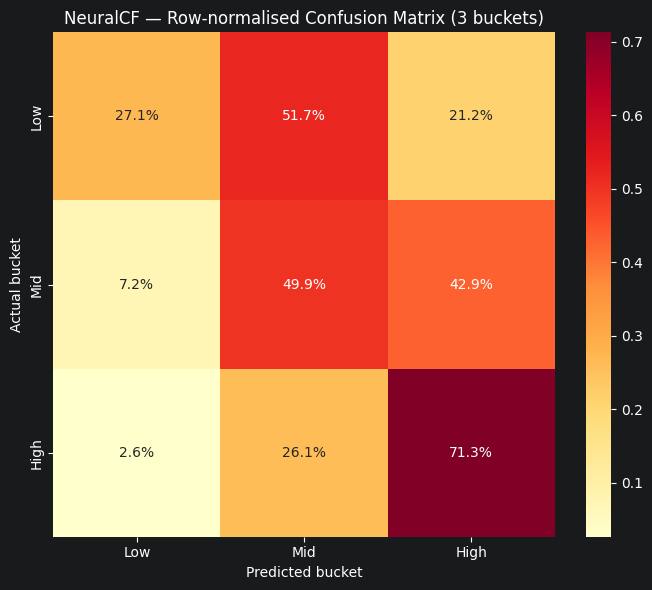

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def bucket(ratings):
    return pd.cut(
        ratings,
        bins=[0, 2.5, 3.5, 5.01],
        labels=["Low (≤2.5)", "Mid (3–3.5)", "High (≥4)"]
    )

true_buckets = bucket(best_ncf_true)
pred_buckets = bucket(np.clip(best_ncf_preds, 0.5, 5.0))

cm3 = confusion_matrix(true_buckets, pred_buckets,
                        labels=["Low (≤2.5)", "Mid (3–3.5)", "High (≥4)"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm3 / cm3.sum(axis=1, keepdims=True),  # row-normalise → recall per class
    annot=True, fmt=".1%", cmap="YlOrRd",
    xticklabels=["Low", "Mid", "High"],
    yticklabels=["Low", "Mid", "High"], ax=ax
)
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("Actual bucket")
ax.set_title("NeuralCF — Row-normalised Confusion Matrix (3 buckets)")
plt.tight_layout()
plt.show()

## Per-User Showcase — Liked Movies vs. NCF Recommendations
For a handful of test users we display:
- **Liked in training** — up to 5 movies rated ≥ 4.0 during training (what the model *learned* from).
- **Rated in test** — actual high-rated movies the user gave ≥ 4.0 in the held-out period.
- **NCF Top-10** — movies the model ranks highest among everything the user has *never* rated.

The model scores every unrated movie for each sampled user using the trained `model_ncf` (genre-aware).

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Per-user showcase: liked movies in training vs. NCF top-N recommendations
# ─────────────────────────────────────────────────────────────────────────────
import textwrap

N_SAMPLE_USERS = 5
TOP_N          = 5
MIN_LIKED      = 5   # skip users who barely rated anything

# ── Lookup helpers (idx_to_movie / all_movie_ids / genre_mat defined in R_aug cell) ──
movie_title   = movies.set_index("movieId")["title"]
movie_genres  = movies.set_index("movieId")["genres"]

genre_tensor_all = torch.tensor(genre_mat, dtype=torch.float32).to(DEVICE)

# ── Pick sample users ─────────────────────────────────────────────────────────
liked_train       = df_train[df_train["rating"] >= 4.0]
eligible_users    = (
    liked_train.groupby("user_idx").size()
    .pipe(lambda s: s[s >= MIN_LIKED])
    .index.tolist()
)
rng_sc            = np.random.default_rng(42)
sample_user_idxs  = rng_sc.choice(eligible_users, size=N_SAMPLE_USERS, replace=False)

model_ncf.eval()

def fmt_movie(mid, extra=""):
    title  = movie_title.get(mid, "Unknown")
    genres = movie_genres.get(mid, "")
    genres_short = ", ".join(genres.split("|")[:3])  # first 3 genres max
    return f"{title}  [{genres_short}]{extra}"

sep = "─" * 80

for u_idx in sample_user_idxs:
    print(sep)
    print(f"  USER  idx={u_idx}")
    print(sep)

    # ── Liked in training (up to 5, sorted by rating desc) ────────────────
    liked_rows = (
        liked_train[liked_train["user_idx"] == u_idx]
        .nlargest(5, "rating")[["movieId", "rating"]]
    )
    print("  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):")
    for _, row in liked_rows.iterrows():
        print(f"      {row['rating']:.1f}★  {fmt_movie(int(row['movieId']))}")

    # ── NCF recommendations: score all unrated movies ─────────────────────
    rated_set   = set(df_train[df_train["user_idx"] == u_idx]["movie_idx"].values)
    unrated     = [i for i in range(N_MOVIES) if i not in rated_set]
    u_t         = torch.full((len(unrated),), u_idx, dtype=torch.long).to(DEVICE)
    m_t         = torch.tensor(unrated, dtype=torch.long).to(DEVICE)
    g_t         = genre_tensor_all[m_t]
    with torch.no_grad():
        scores = model_ncf(u_t, m_t, g_t).cpu().numpy()
    top_k_pos = np.argsort(scores)[::-1][:TOP_N]

    print(f"\n  ⭐ NCF TOP-{TOP_N} RECOMMENDATIONS (unrated movies, by predicted score):")
    for rank, pos in enumerate(top_k_pos, 1):
        mid   = idx_to_movie[unrated[pos]]
        score = scores[pos]
        print(f"      {rank:>2}. ({score:+.2f})  {fmt_movie(mid)}")

    print()

print(sep)


────────────────────────────────────────────────────────────────────────────────
  USER  idx=106722
────────────────────────────────────────────────────────────────────────────────
  ★ LIKED IN TRAINING (top-5 rated ≥ 4.0):
      5.0★  Toy Story (1995)  [Adventure, Animation, Children]
      5.0★  Get Shorty (1995)  [Comedy, Crime, Thriller]
      5.0★  Leaving Las Vegas (1995)  [Drama, Romance]
      5.0★  Dead Man Walking (1995)  [Crime, Drama]
      5.0★  To Die For (1995)  [Comedy, Drama, Thriller]

  ⭐ NCF TOP-5 RECOMMENDATIONS (unrated movies, by predicted score):
       1. (+5.57)  The Life and Mind of Mark DeFriest (2014)  [Animation, Crime, Documentary]
       2. (+5.43)  Ryan (2004)  [Animation, Documentary, Drama]
       3. (+5.34)  Desert of Forbidden Art, The (2010)  [Adventure, Documentary, Drama]
       4. (+5.30)  Bananas!* (2009)  [Crime, Documentary, Drama]
       5. (+5.05)  Hell and Back Again (2011)  [Documentary, Drama, War]

──────────────────────────────────────